# 8. The method of least squares

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import poisson
import matplotlib.pyplot as plt 
import math
from sklearn.linear_model import LinearRegression
import seaborn as sns

**1. [# 25]** Полезный объём древесины (в кубических метрах), высота (в метрах) и диаметр (в метрах) (измеренные на высоте 1.37 метра над землей) зарегистрированы для 31 дерева черной вишни. Данные приведены в таблице measurements_black_cherry_trees.xlsx. Они были собраны для определения оценки объема дерева (и, следовательно, выхода древесины) с учетом его высоты и диаметра. Для каждого дерева записываются объем $y$ и значение $x = d^2h$, где $d$ и $h$ – диаметр и высота дерева. Постройте модель линейной регрессии и оцените его качество.


**a.** Какие физические причины оправдывают линейную зависимость между $y$ и $d^2h$?

Геометрические соображения: Объем цилиндра (дерева) можно выразить как произведение площади основания на высоту. Площадь основания пропорциональна квадрату диаметра ($d^2$), а высота ($h$) также влияет на объем. При фиксированном диаметре увеличение высоты приводит к увеличению объема, и наоборот.

**б.** Для оценки коэффициента $\beta$ прямой $y = \beta x + \alpha$ предлагается три способа:
1) «средний наклон» $zn$, где $zi = yi /xi$;
2) «наклон средних значений» $y/x$;
3) оценка $\beta$ , построенная методом наименьших квадратов.
Вычислите все три оценки и постройте графики функций $y = \beta x$ с разными угловыми
коэффициентами $\beta$. Найдите и сравните сумму квадратов остатков и сделайте выводы.

In [17]:
df_ch = pd.read_excel('measurements_black_cherry_trees.xlsx')

df_ch

,Diameter,Height,Volume
0,0.21,21.3,0.29
1,0.22,19.8,0.29
2,0.22,19.2,0.29
3,0.27,21.9,0.46
4,0.27,24.7,0.53
5,0.27,25.3,0.56
6,0.28,20.1,0.44
7,0.28,22.9,0.52
8,0.28,24.4,0.64
9,0.28,22.9,0.56


Text(0.5, 0, 'd^2h')

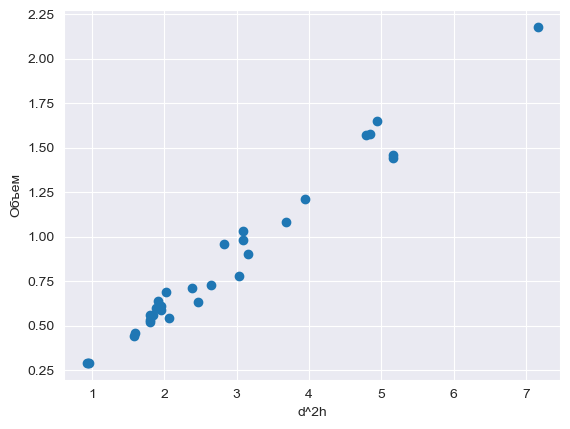

In [18]:
xs = []
for i in range(len(df_ch['Diameter'])):
    xs.append(df_ch['Diameter'][i]**2 * df_ch['Height'][i])
plt.scatter(x=xs, y=df_ch['Volume'])
plt.ylabel("Объем")
plt.xlabel("d^2h")

средний наклон = 0.3024611199883203
наклон средних значений = 0.3032032103384744


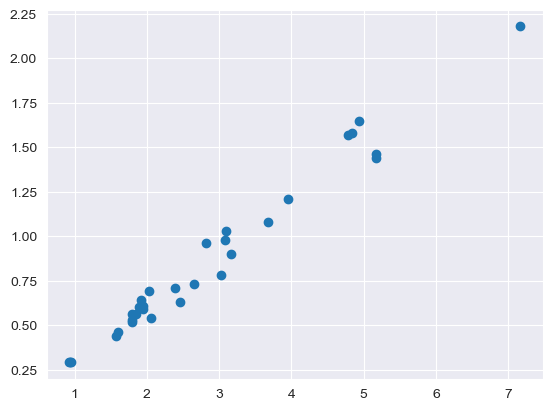

In [7]:
z = []

for i in range(len(df_ch['Diameter'])):
    z.append(df_ch['Volume'][i] / (df_ch['Diameter'][i]**2 * df_ch['Height'][i]))

z_mean = np.mean(z)
yx_mean = np.mean(df_ch['Volume']) / np.mean(xs)
model = LinearRegression()
model.fit(np.array(xs).reshape(-1, 1), df_ch['Volume'].values)
y_pred = model.predict(np.array(xs).reshape(-1, 1))

print('средний наклон =', z_mean)
print('наклон средних значений =', yx_mean)

plt.scatter(x=xs, y=df_ch['Volume'])

In [8]:
reshaped_x = np.array(xs).reshape(-1, 1)

model = LinearRegression()
model.fit(reshaped_x, df_ch['Volume'])
y_pred = model.predict(reshaped_x)
print('Slope: {:.3f}'.format(model.coef_[0]))
print('Intercept: {:.3f}'.format(model.intercept_))

slope_least_squares = model.coef_[0]

Slope: 0.308
Intercept: -0.012


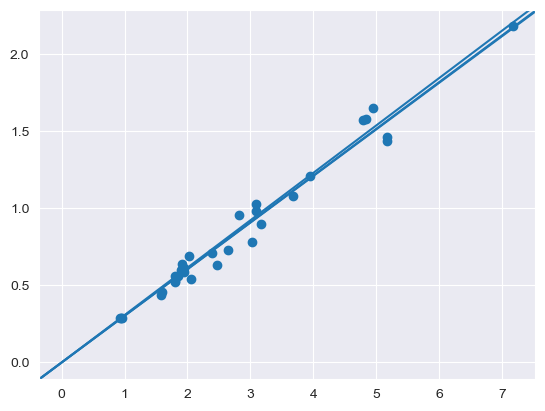

In [9]:
plt.axline((0, 0), slope=z_mean)
plt.axline((0, 0), slope=yx_mean)
plt.axline((0, 0), slope=slope_least_squares)
plt.scatter(x=xs, y=df_ch['Volume'])

**2. [# 25]** Для набора данных о древесине естественным является $\alpha = 0$ («нет твердости без плотности»):<br>
$Yi = \beta xi + Ui для i = 1,2,..., n.$ <br>
Найдите оценку $\beta$ методом наименьших квадратов путем минимизации соответствующей суммы квадратов. Проведите анализ данной модели и сравните с моделью, построенной на лекции, и сделайте выводы.

In [15]:
df = pd.read_excel('measurements_black_cherry_trees.xlsx')
df.columns = ["Volume", "Height", "Diameter"]

x = df["Volume"].values.reshape(-1, 1)
y = df["Diameter"] * df["Height"]

model = LinearRegression()
model.fit(x, y)

beta_estimate = model.coef_[0]

print("Оценка коэффициента beta методом наименьших квадратов:", beta_estimate)

Оценка коэффициента beta методом наименьших квадратов: 144.9794647094719
